# 3.3 Оценка временных характеристик

**Агент** оценивает время освоения:
- каждого учебного материала (с учётом сложности и медиаконтента)
- каждого предмета/дисциплины
- набора предметов с учётом **параллельного** и **последовательного** изучения

Визуализация: диаграмма Ганта, столбчатые диаграммы, сводная таблица.

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path
from datetime import datetime, timedelta

from src.config import (
    WORDS_PER_MINUTE, COMPLEXITY_MULTIPLIERS,
    MEDIA_TIME_MIN, VIDEO_TIME_MIN, QUESTION_TIME_MIN
)
from src.db import load_labelled_materials

REPORTS = Path('../reports')
REPORTS.mkdir(exist_ok=True)
print('Импорты загружены. Python', sys.version)

Импорты загружены. Python 3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]


## 1. Загрузка данных

In [2]:
df = load_labelled_materials()
print(f'Материалов: {len(df)}, предметов: {df["subject"].nunique()}')
df[['subject', 'topic', 'word_count', 'complexity_cluster', 'difficulty_label',
    'parallel_cluster', 'sequential_cluster']].head(5)

Материалов: 8, предметов: 5


,subject,topic,word_count,complexity_cluster,difficulty_label,parallel_cluster,sequential_cluster
0,Экология,Введение в экологию и основы охраны природы,244.0,0,Базовый,0,3
1,Экология,Основы экологии и охрана природы,1356.0,1,Средний,3,1
2,Окружающий мир,Рабочая тетрадь по курсу «Окружающий мир» для ...,664.0,1,Средний,3,1
3,Естествознание / Окружающий мир,Основные понятия природы и живых организмов,108.0,1,Средний,3,1
4,Анализ данных,Данные об успеваемости учащихся,5305.0,2,Продвинутый,2,1


## 2. Расчёт времени освоения каждого материала

**Формула:**
```
t_base = word_count / WORDS_PER_MINUTE
t_material = t_base × complexity_multiplier
           + has_images × MEDIA_TIME_MIN
           + has_videos × VIDEO_TIME_MIN
           + has_questions × QUESTION_TIME_MIN
```

Множители сложности: Базовый × 1.0, Средний × 1.4, Продвинутый × 2.0

In [3]:
def estimate_material_time(row) -> float:
    """Returns estimated study time in minutes."""
    wc   = max(float(row.get('word_count') or 0), 0)
    mult = COMPLEXITY_MULTIPLIERS.get(int(row.get('complexity_cluster', 1)), 1.4)

    t_base      = wc / WORDS_PER_MINUTE
    t_images    = float(row.get('has_images', 0) or 0)    * MEDIA_TIME_MIN
    t_videos    = float(row.get('has_videos', 0) or 0)    * VIDEO_TIME_MIN
    t_questions = float(row.get('has_questions', 0) or 0) * QUESTION_TIME_MIN

    return round(t_base * mult + t_images + t_videos + t_questions, 2)

df['time_min'] = df.apply(estimate_material_time, axis=1)
df['time_hours'] = (df['time_min'] / 60).round(3)

print('Топ-5 самых объёмных материалов:')
print(df[['title', 'subject', 'difficulty_label', 'time_min']]
      .sort_values('time_min', ascending=False).head(5).to_string(index=False))

print(f'\nСреднее время на материал: {df["time_min"].mean():.1f} мин')
print(f'Общее время (последовательно): {df["time_min"].sum():.0f} мин = {df["time_min"].sum()/60:.1f} ч')

Топ-5 самых объёмных материалов:
                                                 title        subject difficulty_label  time_min
                       Данные об успеваемости учащихся  Анализ данных      Продвинутый     53.05
                      Основы экологии и охрана природы       Экология          Средний     12.49
                     Олимпиадные задачи по информатике    Информатика          Средний      9.68
Рабочая тетрадь по курсу «Окружающий мир» для 3 класса Окружающий мир          Средний      7.65
               Поисковые запросы и логические операции    Информатика          Средний      3.81

Среднее время на материал: 11.6 мин
Общее время (последовательно): 93 мин = 1.5 ч


## 3. Время по предметам

In [4]:
subject_time = (
    df.groupby('subject')
    .agg(
        materials=('id', 'count'),
        time_seq_min=('time_min', 'sum'),
        parallel_clusters=('parallel_cluster', 'nunique'),
    )
    .reset_index()
)

# Параллельное время: внутри одного предмета группируем по parallel_cluster
# и берём максимальную длительность по каждому кластеру
def parallel_time_for_subject(sub_df):
    cluster_times = sub_df.groupby('parallel_cluster')['time_min'].sum()
    return cluster_times.max()  # параллельные потоки — итог определяется самым долгим

par_times = df.groupby('subject').apply(parallel_time_for_subject).reset_index()
par_times.columns = ['subject', 'time_par_min']

subject_time = subject_time.merge(par_times, on='subject')
subject_time['time_seq_h']  = (subject_time['time_seq_min'] / 60).round(2)
subject_time['time_par_h']  = (subject_time['time_par_min'] / 60).round(2)
subject_time['saving_pct']  = (
    (1 - subject_time['time_par_min'] / subject_time['time_seq_min']) * 100
).round(1)

print('=== Время по предметам (минуты) ===')
print(subject_time[['subject', 'materials', 'time_seq_min', 'time_par_min', 'saving_pct']]
      .to_string(index=False))

=== Время по предметам (минуты) ===
                        subject  materials  time_seq_min  time_par_min  saving_pct
                  Анализ данных          1         53.05         53.05         0.0
Естествознание / Окружающий мир          1          3.76          3.76         0.0
                    Информатика          2         13.49         13.49         0.0
                 Окружающий мир          1          7.65          7.65         0.0
                       Экология          3         14.93         12.49        16.3


## 4. Визуализация — столбчатые диаграммы

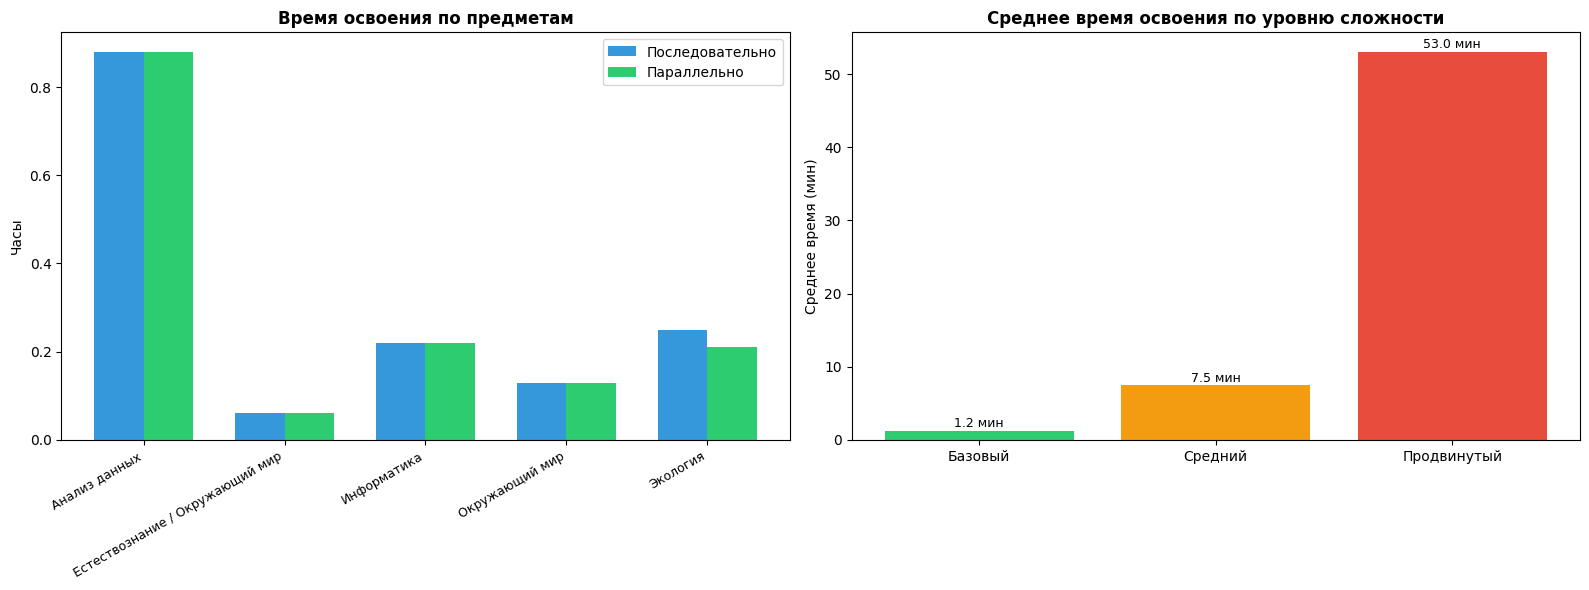

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Последовательное vs параллельное время ---
ax = axes[0]
x  = range(len(subject_time))
w  = 0.35
ax.bar([xi - w/2 for xi in x], subject_time['time_seq_h'], width=w,
       label='Последовательно', color='#3498db')
ax.bar([xi + w/2 for xi in x], subject_time['time_par_h'], width=w,
       label='Параллельно', color='#2ecc71')
ax.set_xticks(list(x))
ax.set_xticklabels(subject_time['subject'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Часы')
ax.set_title('Время освоения по предметам', fontweight='bold')
ax.legend()

# --- Распределение материалов по сложности ---
ax2 = axes[1]
complexity_time = df.groupby('difficulty_label')['time_min'].agg(['mean', 'sum']).reset_index()
order = ['Базовый', 'Средний', 'Продвинутый']
complexity_time = complexity_time.set_index('difficulty_label').reindex(
    [o for o in order if o in complexity_time['difficulty_label'].values]
).reset_index()
ax2.bar(complexity_time['difficulty_label'], complexity_time['mean'],
        color=['#2ecc71', '#f39c12', '#e74c3c'])
ax2.set_ylabel('Среднее время (мин)')
ax2.set_title('Среднее время освоения по уровню сложности', fontweight='bold')
for i, (_, row) in enumerate(complexity_time.iterrows()):
    ax2.text(i, row['mean'] + 0.5, f'{row["mean"]:.1f} мин', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(REPORTS / 'time_by_subject.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Диаграмма Ганта — план изучения набора предметов

In [6]:
def build_gantt_data(subject_time_df, daily_hours=4.0, start_date=None):
    """Build Gantt chart DataFrame: each subject as a bar with start/end date."""
    if start_date is None:
        start_date = datetime.today().replace(hour=0, minute=0, second=0, microsecond=0)

    # Separate subjects by parallel_clusters into lanes
    # Subjects sharing the same parallel start time = same 'week slot'
    gantt_rows = []
    current_date = start_date

    # Simple sequential order for Gantt (real parallelism handled in section 3)
    for _, row in subject_time_df.sort_values('time_seq_h', ascending=False).iterrows():
        days_needed = max(1, int(np.ceil(row['time_seq_h'] / daily_hours)))
        end_date    = current_date + timedelta(days=days_needed)
        gantt_rows.append({
            'Предмет': row['subject'],
            'Начало': current_date,
            'Конец': end_date,
            'Дней': days_needed,
            'Часов всего': row['time_seq_h'],
        })
        current_date = end_date

    return pd.DataFrame(gantt_rows)

gantt_df = build_gantt_data(subject_time, daily_hours=4.0)
print(gantt_df[['Предмет', 'Начало', 'Конец', 'Дней', 'Часов всего']].to_string(index=False))

                        Предмет     Начало      Конец  Дней  Часов всего
                  Анализ данных 2026-04-23 2026-04-24     1         0.88
                       Экология 2026-04-24 2026-04-25     1         0.25
                    Информатика 2026-04-25 2026-04-26     1         0.22
                 Окружающий мир 2026-04-26 2026-04-27     1         0.13
Естествознание / Окружающий мир 2026-04-27 2026-04-28     1         0.06


In [7]:
# Plotly Gantt chart
colors = px.colors.qualitative.Set2

fig = px.timeline(
    gantt_df,
    x_start='Начало',
    x_end='Конец',
    y='Предмет',
    color='Предмет',
    text='Дней',
    title='Диаграмма Ганта — план последовательного освоения предметов (4 ч/день)',
    labels={'Предмет': 'Дисциплина'},
    color_discrete_sequence=colors,
)
fig.update_yaxes(autorange='reversed')
fig.update_layout(
    height=max(300, 60 * len(gantt_df)),
    font=dict(size=12),
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='#eeeeee'),
)
fig.update_traces(textposition='inside')
fig.write_html(str(REPORTS / 'gantt_sequential.html'))
fig.show()
print('Сохранено: reports/gantt_sequential.html')

Сохранено: reports/gantt_sequential.html


## 6. Параллельный план: несколько предметов одновременно

In [8]:
def build_parallel_gantt(df, subject_time_df, daily_hours=4.0, start_date=None):
    """
    Параллельный план: материалы из разных parallel_cluster-групп
    изучаются одновременно. Итоговое время = max(длительность кластеров).
    """
    if start_date is None:
        start_date = datetime.today().replace(hour=0, minute=0, second=0, microsecond=0)

    # Group subjects by parallel cluster assignment
    par_groups = (
        df.groupby(['parallel_cluster', 'subject'])['time_min'].sum()
        .reset_index()
        .rename(columns={'time_min': 'group_time_min'})
    )

    rows = []
    current_date = start_date

    for cluster_id, group_df in par_groups.groupby('parallel_cluster'):
        max_time_h = group_df['group_time_min'].max() / 60
        days_needed = max(1, int(np.ceil(max_time_h / daily_hours)))
        end_date = current_date + timedelta(days=days_needed)

        for _, row in group_df.iterrows():
            t_h   = row['group_time_min'] / 60
            d_sub = max(1, int(np.ceil(t_h / daily_hours)))
            rows.append({
                'Предмет': row['subject'],
                'Поток': f'Поток {cluster_id}',
                'Начало': current_date,
                'Конец': current_date + timedelta(days=d_sub),
                'Часов': round(t_h, 1),
            })
        current_date = end_date  # Next cluster starts after this batch

    return pd.DataFrame(rows)

par_gantt_df = build_parallel_gantt(df, subject_time, daily_hours=4.0)

fig2 = px.timeline(
    par_gantt_df,
    x_start='Начало',
    x_end='Конец',
    y='Предмет',
    color='Поток',
    text='Часов',
    title='Параллельный план освоения (материалы из одного кластера изучаются одновременно)',
    color_discrete_sequence=px.colors.qualitative.Pastel,
)
fig2.update_yaxes(autorange='reversed')
fig2.update_layout(
    height=max(300, 60 * len(par_gantt_df)),
    font=dict(size=12),
    plot_bgcolor='white',
)
fig2.update_traces(textposition='inside')
fig2.write_html(str(REPORTS / 'gantt_parallel.html'))
fig2.show()
print('Сохранено: reports/gantt_parallel.html')

Сохранено: reports/gantt_parallel.html


## 7. Сводная таблица временных характеристик

In [9]:
total_seq_h = subject_time['time_seq_h'].sum()

# Параллельное время всего набора: кластеры выполняются последовательно,
# но внутри каждого кластера предметы идут параллельно
cluster_max_times = (
    df.groupby('parallel_cluster')['time_min'].sum() / 60
).reset_index()
total_par_h = cluster_max_times['time_min'].sum()

print('=== СВОДКА ВРЕМЕННЫХ ХАРАКТЕРИСТИК ===')
print(f'\nВсего материалов: {len(df)}')
print(f'Предметов: {df["subject"].nunique()}')
print()
print(f'Общее время (последовательно): {total_seq_h:.1f} ч  = {total_seq_h/8:.1f} учебных дней')
print(f'Общее время (с параллелизмом): {total_par_h:.1f} ч  = {total_par_h/8:.1f} учебных дней')
print(f'Экономия за счёт параллелизма: {(1 - total_par_h/total_seq_h)*100:.1f}%')
print()
print('По предметам:')
print(subject_time[['subject', 'materials', 'time_seq_h', 'time_par_h', 'saving_pct']]
      .rename(columns={
          'time_seq_h': 'Посл. (ч)',
          'time_par_h': 'Парал. (ч)',
          'saving_pct': 'Экономия %'
      }).to_string(index=False))

subject_time.to_csv(REPORTS / 'time_estimation_summary.csv', index=False, encoding='utf-8')
print('\nСохранено: reports/time_estimation_summary.csv')

=== СВОДКА ВРЕМЕННЫХ ХАРАКТЕРИСТИК ===

Всего материалов: 8
Предметов: 5

Общее время (последовательно): 1.5 ч  = 0.2 учебных дней
Общее время (с параллелизмом): 1.5 ч  = 0.2 учебных дней
Экономия за счёт параллелизма: -0.5%

По предметам:
                        subject  materials  Посл. (ч)  Парал. (ч)  Экономия %
                  Анализ данных          1       0.88        0.88         0.0
Естествознание / Окружающий мир          1       0.06        0.06         0.0
                    Информатика          2       0.22        0.22         0.0
                 Окружающий мир          1       0.13        0.13         0.0
                       Экология          3       0.25        0.21        16.3

Сохранено: reports/time_estimation_summary.csv


## 8. Визуализация: box-plot времени по предметам

In [10]:
fig3 = px.box(
    df,
    x='subject',
    y='time_min',
    color='difficulty_label',
    title='Распределение времени освоения материалов по предметам и уровню сложности',
    labels={'time_min': 'Время (мин)', 'subject': 'Предмет', 'difficulty_label': 'Сложность'},
    color_discrete_map={'Базовый': '#2ecc71', 'Средний': '#f39c12', 'Продвинутый': '#e74c3c'},
)
fig3.update_layout(height=500, xaxis_tickangle=-30)
fig3.write_html(str(REPORTS / 'time_boxplot.html'))
fig3.show()
print('Сохранено: reports/time_boxplot.html')

Сохранено: reports/time_boxplot.html
